#Workflow:

1. Inspection of the video
2. Extracting frames using Python
3. Review and removal of poor-quality frames if any
4. Creation of the image metadata
5. Image preprocessing
6. Image augmentation
7. Building the image model
8. Creation of process-variable dataset
9. Synchronize images and process data
10. Build the multimodal model
11. Evaluate and interpret the results

## Project Overview

This project presents a proof-of-concept multimodal deep-learning system for detecting foamy-slag conditions in an Electric Arc Furnace using furnace 
images and synthetic process variables. 
The slag images were extracted from a YouTube video published on the **Alec Steele** channel and classified as foamy or non-foamy slag based on 
their visible characteristics. 
The image features were combined with generated process variables, including arc voltage, arc current, power input, oxygen flow, carbon injection, 
off-gas temperature, CO, and CO₂.

The image dataset is limited because it contains only 18 closely related frames from one short video rather than independent images from 
different furnaces and heats. The process dataset is also synthetic and partly generated in relation to the assigned slag labels. 
Consequently, the models may learn from simplified patterns, and their predictions cannot be considered evidence of industrial performance or 
generalisation. Both the image-only and multimodal models achieved perfect validation accuracy, precision, recall, F1-score, and ROC-AUC on the 
six-image validation set. Loss values were therefore used to compare their prediction confidence, since lower loss indicates probabilities 
closer to the correct labels. Nevertheless, the results are presented strictly as a demonstration of the complete multimodal workflow and 
proof that the proposed architecture can be implemented before validation with real plant data.


In [49]:
import cv2
import os
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    RandomFlip,
    RandomRotation,
    RandomZoom,
    RandomContrast
)


from tensorflow.keras import Model
from tensorflow.keras.layers import (
    Input,
    Rescaling,
    GlobalAveragePooling2D,
    Dropout,
    Dense
)
from tensorflow.keras.applications import MobileNetV2

In [50]:
#Inspection of the video

video_path = r"C:\Users\uched\Documents\EAF Research\Multi_Modal Project\Foamy_Slag video.mp4"

video = cv2.VideoCapture(video_path)

if not video.isOpened():
    print("Error: The video could not be opened.")
else: 
    fps = video.get(cv2.CAP_PROP_FPS)
    total_frames = int(video.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(video.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video.get(cv2.CAP_PROP_FRAME_HEIGHT))
    duration = total_frames/fps

    print(f"Frame rate: {fps:.2f} FPS")
    print(f"Total frames: {total_frames}")
    print(f"Resolution: {width} x {height}")
    print(f"Duration: {duration:.2f} seconds")

video.release()

Frame rate: 30.00 FPS
Total frames: 309
Resolution: 1920 x 1080
Duration: 10.30 seconds


In [51]:
#Extraction of Images/frames

output_folder = r"C:\Users\uched\Documents\EAF Research\Multi_Modal Project\foamy_slag_frames"

os.makedirs(output_folder, exist_ok= True)

video = cv2.VideoCapture(video_path)

if not video.isOpened():
    print("Error: The video could not be opened")

else:
    start_time = 0.0
    end_time = 9.0
    extraction_interval = 0.5

    current_time = start_time
    image_number = 1

    while current_time < end_time:

        video.set(cv2.CAP_PROP_POS_MSEC, current_time * 1000)
        success, frame = video.read()

        if not success:
            print(f"Could not read the frame at {current_time:.2f} seconds.")
            break

        filename = (
            f"foamy_slag_{image_number:03d}_"
            f"{current_time:.2f}s.jpg"
        )

        output_path = os.path.join(output_folder, filename)

        saved = cv2.imwrite(output_path, frame)

        if saved:
            print(f"Saved: {filename}")
        else:
            print(f"Failed to save: {filename}")
            
        image_number += 1
        current_time += extraction_interval

video.release()

print(f"\nTotal images extracted: {image_number - 1}")
print(f"Images saved in: {output_folder} ")

Saved: foamy_slag_001_0.00s.jpg
Saved: foamy_slag_002_0.50s.jpg
Saved: foamy_slag_003_1.00s.jpg
Saved: foamy_slag_004_1.50s.jpg
Saved: foamy_slag_005_2.00s.jpg
Saved: foamy_slag_006_2.50s.jpg
Saved: foamy_slag_007_3.00s.jpg
Saved: foamy_slag_008_3.50s.jpg
Saved: foamy_slag_009_4.00s.jpg
Saved: foamy_slag_010_4.50s.jpg
Saved: foamy_slag_011_5.00s.jpg
Saved: foamy_slag_012_5.50s.jpg
Saved: foamy_slag_013_6.00s.jpg
Saved: foamy_slag_014_6.50s.jpg
Saved: foamy_slag_015_7.00s.jpg
Saved: foamy_slag_016_7.50s.jpg
Saved: foamy_slag_017_8.00s.jpg
Saved: foamy_slag_018_8.50s.jpg

Total images extracted: 18
Images saved in: C:\Users\uched\Documents\EAF Research\Multi_Modal Project\foamy_slag_frames 


Number of images found: 18


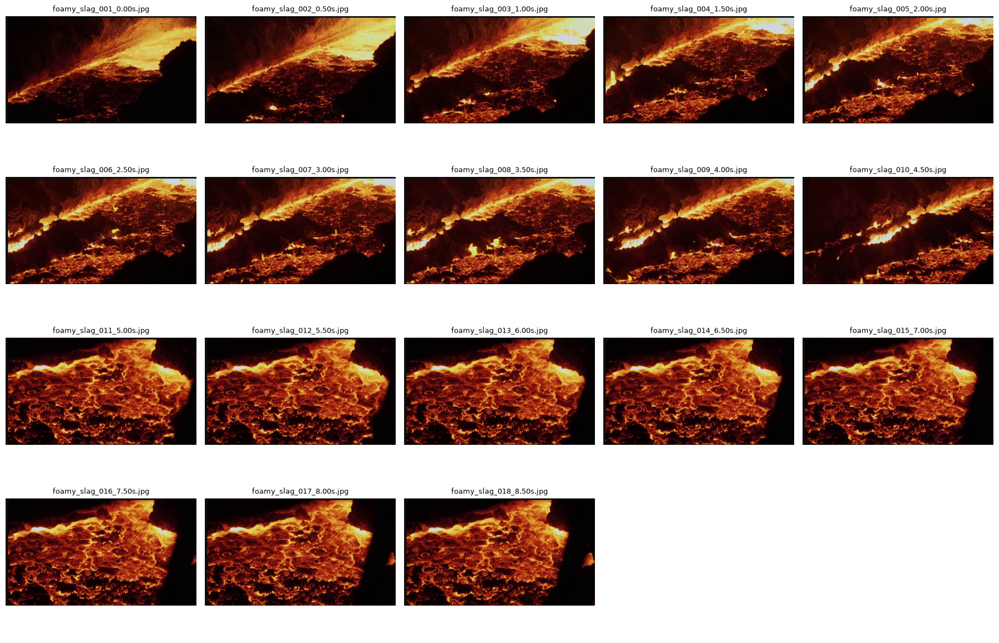

In [52]:
#Display of Images

image_folder = r"C:\Users\uched\Documents\EAF Research\Multi_Modal Project\foamy_slag_frames"

image_files = ([
    file for file in os.listdir(image_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"Number of images found: {len(image_files)}")

fig, axes = plt.subplots(4, 5, figsize=(18,12))
axes = axes.flatten()

for index, ax in enumerate(axes):

    if index < len(image_files):
        image_path = os.path.join(image_folder, image_files[index])

        image = cv2.imread(image_path)

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        ax.imshow(image_rgb)
        ax.set_title(image_files[index], fontsize=9)
        ax.axis("off")

    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

In [53]:
#Creation of image metadata

metadata = []

for image_number, filename in enumerate(image_files, start=1):

    
    timestamp_text = filename.split("_")[-1]
    timestamp = float(timestamp_text.replace("s.jpg", ""))

    
    if image_number <= 10:
        label = "non_foamy_slag"
        class_id = 0
        sequence_group = "sequence_1_wide_view"

    else:
        label = "foamy_slag"
        class_id = 1
        sequence_group = "sequence_2_close_view"

    metadata.append({
        "image_id": image_number,
        "filename": filename,
        "timestamp_seconds": timestamp,
        "label": label,
        "class_id": class_id,
        "source_video": "slag video",
        "sequence_group": sequence_group
    })

metadata_df = pd.DataFrame(metadata)

metadata_df

,image_id,filename,timestamp_seconds,label,class_id,source_video,sequence_group
0,1,foamy_slag_001_0.00s.jpg,0.0,non_foamy_slag,0,slag video,sequence_1_wide_view
1,2,foamy_slag_002_0.50s.jpg,0.5,non_foamy_slag,0,slag video,sequence_1_wide_view
2,3,foamy_slag_003_1.00s.jpg,1.0,non_foamy_slag,0,slag video,sequence_1_wide_view
3,4,foamy_slag_004_1.50s.jpg,1.5,non_foamy_slag,0,slag video,sequence_1_wide_view
4,5,foamy_slag_005_2.00s.jpg,2.0,non_foamy_slag,0,slag video,sequence_1_wide_view
5,6,foamy_slag_006_2.50s.jpg,2.5,non_foamy_slag,0,slag video,sequence_1_wide_view
6,7,foamy_slag_007_3.00s.jpg,3.0,non_foamy_slag,0,slag video,sequence_1_wide_view
7,8,foamy_slag_008_3.50s.jpg,3.5,non_foamy_slag,0,slag video,sequence_1_wide_view
8,9,foamy_slag_009_4.00s.jpg,4.0,non_foamy_slag,0,slag video,sequence_1_wide_view
9,10,foamy_slag_010_4.50s.jpg,4.5,non_foamy_slag,0,slag video,sequence_1_wide_view


In [54]:
print(metadata_df[[
    "image_id",
    "filename",
    "label",
    "class_id"
]])

print("\nClass counts:")
print(metadata_df["class_id"].value_counts().sort_index())

    image_id                  filename           label  class_id
0          1  foamy_slag_001_0.00s.jpg  non_foamy_slag         0
1          2  foamy_slag_002_0.50s.jpg  non_foamy_slag         0
2          3  foamy_slag_003_1.00s.jpg  non_foamy_slag         0
3          4  foamy_slag_004_1.50s.jpg  non_foamy_slag         0
4          5  foamy_slag_005_2.00s.jpg  non_foamy_slag         0
5          6  foamy_slag_006_2.50s.jpg  non_foamy_slag         0
6          7  foamy_slag_007_3.00s.jpg  non_foamy_slag         0
7          8  foamy_slag_008_3.50s.jpg  non_foamy_slag         0
8          9  foamy_slag_009_4.00s.jpg  non_foamy_slag         0
9         10  foamy_slag_010_4.50s.jpg  non_foamy_slag         0
10        11  foamy_slag_011_5.00s.jpg      foamy_slag         1
11        12  foamy_slag_012_5.50s.jpg      foamy_slag         1
12        13  foamy_slag_013_6.00s.jpg      foamy_slag         1
13        14  foamy_slag_014_6.50s.jpg      foamy_slag         1
14        15  foamy_slag_

In [55]:
#Saving dataframe


metadata_path = os.path.join(
    image_folder,
    "foamy_slag_metadata.csv"
)

metadata_df.to_csv(metadata_path, index= False)

print(f"Metadata saved to: {metadata_path}")
print(f"Metadata shape: {metadata_df.shape}")

Metadata saved to: C:\Users\uched\Documents\EAF Research\Multi_Modal Project\foamy_slag_frames\foamy_slag_metadata.csv
Metadata shape: (18, 7)


In [56]:
#Preprocessing image Function

# CNN models generally require images of the same size. 
#  Every image will be resized to 224 × 224 while preserving its original aspect ratio by adding padding.


def resize_with_padding(image, target_size=(224,224)):

    target_width, target_height = target_size

    original_height, original_width = image.shape[:2]

    scale = min(
        target_width / original_width,
        target_height / original_height
    )

    new_width = int(original_width * scale)
    new_height =  int(original_height * scale)

    resized_image = cv2.resize(
        image,
        (new_width, new_height),
        interpolation = cv2.INTER_AREA
    )

    padded_image = np.zeros(
        (target_height, target_width, 3),
        dtype=np.uint8
    )

    x_offset = (target_width - new_width) // 2
    y_offset = (target_height - new_height) // 2

    padded_image[
        y_offset:y_offset + new_height,
        x_offset:x_offset + new_width
    ] = resized_image

    return padded_image

In [57]:
#Testing the function on one image

sample_filename = image_files[0]
sample_path = os.path.join(image_folder, sample_filename)

original_image = cv2.imread(sample_path)

processed_image = resize_with_padding(
    original_image,
    target_size = (224, 224)
)

print("Original_image:", original_image.shape)
print("Processed_image:", processed_image.shape)

Original_image: (1080, 1920, 3)
Processed_image: (224, 224, 3)


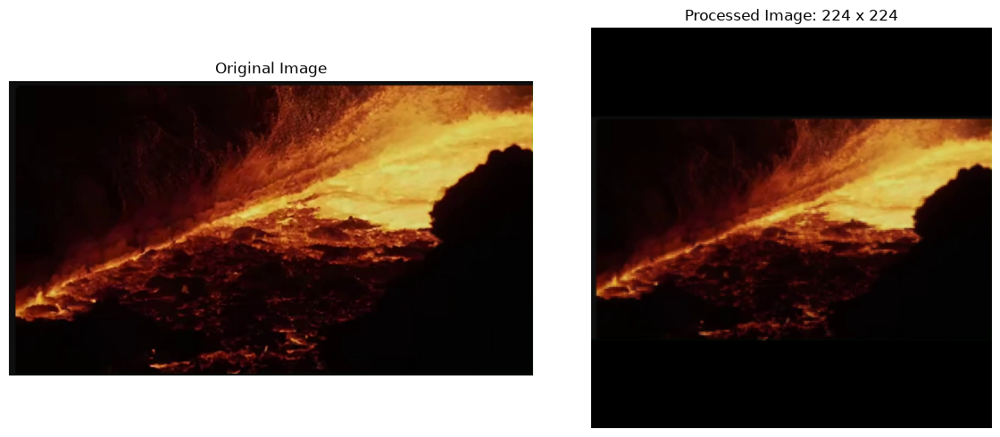

In [58]:
#Comparing the original and processed image

original_rgb = cv2.cvtColor(
    original_image,
    cv2.COLOR_BGR2RGB
)

processed_rgb = cv2.cvtColor(
    processed_image,
    cv2.COLOR_BGR2RGB
)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].imshow(original_rgb)
axes[0].set_title("Original Image")
axes[0].axis("off")

axes[1].imshow(processed_rgb)
axes[1].set_title("Processed Image: 224 x 224")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [59]:
#Preprocessing all 18 pictiures

processed_folder = r"C:\Users\uched\Documents\EAF Research\Multi_Modal Project\processed_foamy_slag_frames"

processed_records = []

os.makedirs(processed_folder, exist_ok=True)

for filename in image_files:

    original_path = os.path.join(image_folder, filename)
    image = cv2.imread(original_path)

    if image is None:
        print(f"Could not read: {filename}")
        continue

    processed_image = resize_with_padding(
        image,
        target_size = (224, 224)
    )

    processed_path = os.path.join(
        processed_folder, 
        filename
    )

    saved_successfully = cv2.imwrite(
        processed_path,
        processed_image
    )

    if saved_successfully:
        processed_records.append(filename)
        print(f"Processed: {filename}")
    else:
        print(f"Could not save: {filename}")

print(f"\nTotal images processed: {len(processed_records)}")

Processed: foamy_slag_001_0.00s.jpg
Processed: foamy_slag_002_0.50s.jpg
Processed: foamy_slag_003_1.00s.jpg
Processed: foamy_slag_004_1.50s.jpg
Processed: foamy_slag_005_2.00s.jpg
Processed: foamy_slag_006_2.50s.jpg
Processed: foamy_slag_007_3.00s.jpg
Processed: foamy_slag_008_3.50s.jpg
Processed: foamy_slag_009_4.00s.jpg
Processed: foamy_slag_010_4.50s.jpg
Processed: foamy_slag_011_5.00s.jpg
Processed: foamy_slag_012_5.50s.jpg
Processed: foamy_slag_013_6.00s.jpg
Processed: foamy_slag_014_6.50s.jpg
Processed: foamy_slag_015_7.00s.jpg
Processed: foamy_slag_016_7.50s.jpg
Processed: foamy_slag_017_8.00s.jpg
Processed: foamy_slag_018_8.50s.jpg

Total images processed: 18


In [60]:
#Verifying the processed image

processed_files = sorted([
    file for file in os.listdir(processed_folder)
    if file.lower().endswith((".jpg", ".jpeg", ".png"))
])

print(f"Processed images found: {len(processed_files)}")

for filename in processed_files:
    image_path = os.path.join(processed_folder, filename)
    image = cv2.imread(image_path)

    if image.shape != (224, 224, 3):
        print(f"Incorrect image: {filename} → {image.shape}")

print("Dimension Verification Complete")

Processed images found: 18
Dimension Verification Complete


In [61]:
#Updating the metadata

metadata_df["processed_filename"] = metadata_df["filename"]
metadata_df["processed_width"] = 224
metadata_df["processed_height"] = 224

metadata_df.to_csv(metadata_path, index=False)

metadata_df.head()

,image_id,filename,timestamp_seconds,label,class_id,source_video,sequence_group,processed_filename,processed_width,processed_height
0,1,foamy_slag_001_0.00s.jpg,0.0,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_001_0.00s.jpg,224,224
1,2,foamy_slag_002_0.50s.jpg,0.5,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_002_0.50s.jpg,224,224
2,3,foamy_slag_003_1.00s.jpg,1.0,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_003_1.00s.jpg,224,224
3,4,foamy_slag_004_1.50s.jpg,1.5,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_004_1.50s.jpg,224,224
4,5,foamy_slag_005_2.00s.jpg,2.0,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_005_2.00s.jpg,224,224


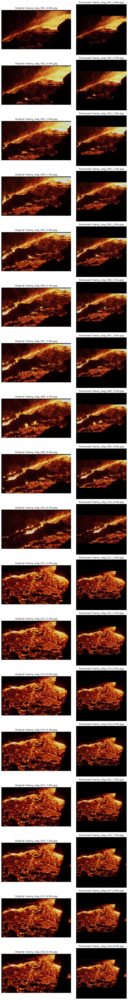

In [62]:
# Visual comparison of original and processed images
# To Check that:

# - The foamy slag region remains visible.
# - The image is not stretched.
# - Nothing important is cropped.
# - Black padding appears only where necessary.

fig, axes = plt.subplots(
    len(image_files),
    2,
    figsize = (10, len(image_files) * 4)
)

for index, filename in enumerate(image_files):

    original_path = os.path.join(image_folder, filename)
    processed_path = os.path.join(processed_folder, filename)

    original_image = cv2.imread(original_path)
    processed_image = cv2.imread(processed_path)

    original_rgb = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
    processed_rgb = cv2.cvtColor(processed_image, cv2.COLOR_BGR2RGB)

    axes[index, 0].imshow(original_rgb)
    axes[index, 0].set_title(f"Original: {filename}")
    axes[index, 0].axis("off")

    axes[index, 1].imshow(processed_rgb)
    axes[index, 1].set_title(f"Processed: {filename}")
    axes[index, 1].axis("off")

plt.tight_layout()
plt.show()

In [63]:


metadata_df["processed_filename"] = metadata_df["filename"]

metadata_df.head()

,image_id,filename,timestamp_seconds,label,class_id,source_video,sequence_group,processed_filename,processed_width,processed_height
0,1,foamy_slag_001_0.00s.jpg,0.0,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_001_0.00s.jpg,224,224
1,2,foamy_slag_002_0.50s.jpg,0.5,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_002_0.50s.jpg,224,224
2,3,foamy_slag_003_1.00s.jpg,1.0,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_003_1.00s.jpg,224,224
3,4,foamy_slag_004_1.50s.jpg,1.5,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_004_1.50s.jpg,224,224
4,5,foamy_slag_005_2.00s.jpg,2.0,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_005_2.00s.jpg,224,224


In [64]:
print("Number of records:", len(metadata_df))
print("\nClass distribution:")
print(metadata_df["label"].value_counts())

print("\nMissing values:")
print(metadata_df.isnull().sum())

Number of records: 18

Class distribution:
label
non_foamy_slag    10
foamy_slag         8
Name: count, dtype: int64

Missing values:
image_id              0
filename              0
timestamp_seconds     0
label                 0
class_id              0
source_video          0
sequence_group        0
processed_filename    0
processed_width       0
processed_height      0
dtype: int64


In [65]:
metadata_path = os.path.join(
    os.path.dirname(processed_folder),
    "foamy_slag_metadata.csv"
)

metadata_df.to_csv(metadata_path, index=False)

print("Metadata saved to:", metadata_path)

Metadata saved to: C:\Users\uched\Documents\EAF Research\Multi_Modal Project\foamy_slag_metadata.csv


In [66]:
#loading the 18 processed images into a NumPy array and normalizing their pixel values for model input.

images = []
labels = []

for _, row in metadata_df.iterrows():

    image_path = os.path.join(
        processed_folder,
        row["processed_filename"]
    )

    image = cv2.imread(image_path)

    if image is None:
        print(f"Could not load: {image_path}")
        continue

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_normalized = image_rgb.astype(np.float32) / 255.0

    images.append(image_normalized)
    labels.append(row["class_id"])

X = np.array(images, dtype=np.float32)
y = np.array(labels, dtype=np.int32)

In [67]:
print(f"Image_array shape:", X.shape)
print(f"Label_array shape:", y.shape)
print(f"Minimum_pixel value:", X.min())
print(f"Maximum_pixel value:", X.max())
print(f"Unique Labels", np.unique(y))

Image_array shape: (18, 224, 224, 3)
Label_array shape: (18,)
Minimum_pixel value: 0.0
Maximum_pixel value: 1.0
Unique Labels [0 1]


In [68]:
train_mask = (
    metadata_df["sequence_group"] == "sequence_1_wide_view"
).to_numpy()

validation_mask = (
    metadata_df["sequence_group"] == "sequence_2_close_view"
).to_numpy()

X_train = X[train_mask]
y_train = y[train_mask]

X_validation = X[validation_mask]
y_validation = y[validation_mask]

#The validation data will only be used to measure whether genuine foamy slag images remain close to the learned foamy slag representation. 
#We cannot measure false positive performance until we obtain non-foamy images.

In [69]:
print("Training-image shape:", X_train.shape)
print("Training-label shape:", y_train.shape)

print("Validation-image shape:", X_validation.shape)
print("Validation-label shape:", y_validation.shape)

print("Training labels:", np.unique(y_train))
print("Validation labels:", np.unique(y_validation))

Training-image shape: (10, 224, 224, 3)
Training-label shape: (10,)
Validation-image shape: (8, 224, 224, 3)
Validation-label shape: (8,)
Training labels: [0]
Validation labels: [1]


In [70]:
print("Number of images:", len(X))
print("Number of labels:", len(y))

assert len(X) == len(y), "X and y do not have the same number of samples."

Number of images: 18
Number of labels: 18


In [71]:
from sklearn.model_selection import train_test_split

X_train, X_validation, y_train, y_validation = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

In [72]:
print("Training-image shape:", X_train.shape)
print("Validation-image shape:", X_validation.shape)

print("Training-label shape:", y_train.shape)
print("Validation-label shape:", y_validation.shape)

print("\nTraining class counts:")
print(np.bincount(y_train))

print("\nValidation class counts:")
print(np.bincount(y_validation))

Training-image shape: (12, 224, 224, 3)
Validation-image shape: (6, 224, 224, 3)
Training-label shape: (12,)
Validation-label shape: (6,)

Training class counts:
[7 5]

Validation class counts:
[3 3]


In [73]:
#Data Augumentation
# Augmentation is used because the training set contains only 10 images, which is far too small for training a CNN reliably.

#This helps the model learn that foamy slag should still be recognised when:

# -The camera position changes slightly.
# -The image is slightly rotated.
# -The furnace is viewed from another direction.
# -Brightness or contrast changes.
# -The slag appears slightly larger or smaller.

    

data_augmentation = Sequential([
    RandomFlip(
        mode="horizontal"
    ),

    RandomRotation(
        factor=0.03,
        fill_mode="reflect"
    ),

    RandomZoom(
        height_factor=(-0.10, 0.10),
        width_factor=(-0.10, 0.10),
        fill_mode="reflect"
    ),

    RandomContrast(
        factor=0.10
    )
], name="data_augmentation")

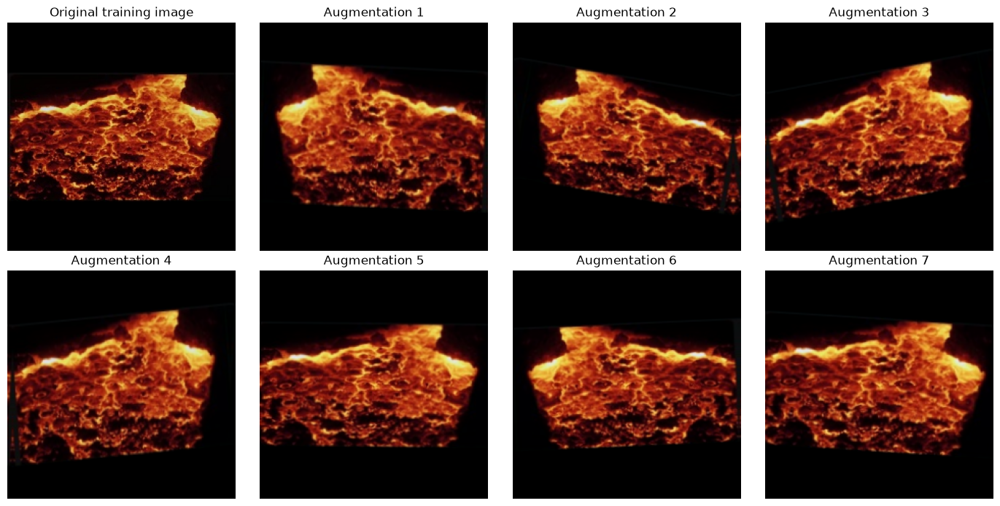

In [74]:
#Visualization of the Augumentation

sample_image = X_train[0]

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

# Display of the original image
axes[0].imshow(sample_image)
axes[0].set_title("Original training image")
axes[0].axis("off")

#  Seven variations are generated
for index in range(1, 8):

    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, axis=0),
        training=True
    )

    augmented_image = tf.squeeze(
        augmented_image,
        axis=0
    )

    # Ensuring values remain within the display range
    augmented_image = tf.clip_by_value(
        augmented_image,
        0.0,
        1.0
    )

    axes[index].imshow(augmented_image.numpy())
    axes[index].set_title(f"Augmentation {index}")
    axes[index].axis("off")

plt.tight_layout()
plt.show()

In [75]:
# Base Model
# Because we only have 10 training images, we will use transfer learning with MobileNetV2. 
#Training a CNN from scratch would likely just memorise the images.

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


base_model.trainable = False

In [76]:
# COMPLETE MODEL

image_input = Input(
    shape=(224, 224, 3),
    name="image_input"
)

# Application of augmentation only during training
x = data_augmentation(image_input)

# Convert values from [0, 1] to [-1, 1]
# MobileNetV2 expects this range
x = Rescaling(
    scale=2.0,
    offset=-1.0,
    name="mobilenet_rescaling"
)(x)

# Extraction of image features
x = base_model(
    x,
    training=False
)

# Converting the feature maps into one feature vector
x = GlobalAveragePooling2D(
    name="image_feature_vector"
)(x)

# Reduce overfitting
x = Dropout(
    rate=0.30,
    name="dropout"
)(x)

# Binary classification output
output = Dense(
    units=1,
    activation="sigmoid",
    name="slag_prediction"
)(x)

image_model = Model(
    inputs=image_input,
    outputs=output,
    name="image_only_foamy_slag_model"
)

In [77]:
image_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

In [78]:
image_model.summary()

Model: "image_only_foamy_slag_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenet_rescaling (Rescaling)      │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ mobilenetv2_1.00_224 (Functional)    │ (None, 7, 7, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ image_feature_vector                 │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1280)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ slag_prediction (Dense)              │ (None, 1)                   │           1,281 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [79]:
# Model callback


from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

model_path = r"C:\Users\uched\Documents\EAF Research\Multi_Modal Project\best_image_model.keras"

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [80]:
# Model Training

history = image_model.fit(
    X_train,
    y_train,
    validation_data=(
        X_validation,
        y_validation
    ),
    epochs=30,
    batch_size=4,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - accuracy: 0.4167 - auc: 0.4286 - loss: 0.8929 - precision: 0.2500 - recall: 0.2000          
Epoch 1: val_loss improved from None to 0.76902, saving model to C:\Users\uched\Documents\EAF Research\Multi_Modal Project\best_image_model.keras

Epoch 1: finished saving model to C:\Users\uched\Documents\EAF Research\Multi_Modal Project\best_image_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 23s 4s/step - accuracy: 0.4167 - auc: 0.4286 - loss: 0.8929 - precision: 0.2500 - recall: 0.2000 - val_accuracy: 0.5000 - val_auc: 1.0000 - val_loss: 0.7690 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7500 - auc: 0.8000 - loss: 0.5177 - precision: 0.6667 - recall: 0.8000
Epoch 2: val_loss improved from 0.76902 to 0.56627, saving model to C:\Users\uched\Documents\EAF Research\Multi_Modal Project\best_image_model.keras

Epoch 2: finished saving model to C:\Users\uched\

In [81]:
completed_epochs = len(history.history["loss"])

print("Completed epochs:", completed_epochs)
print("Best model saved to:", model_path)

Completed epochs: 30
Best model saved to: C:\Users\uched\Documents\EAF Research\Multi_Modal Project\best_image_model.keras


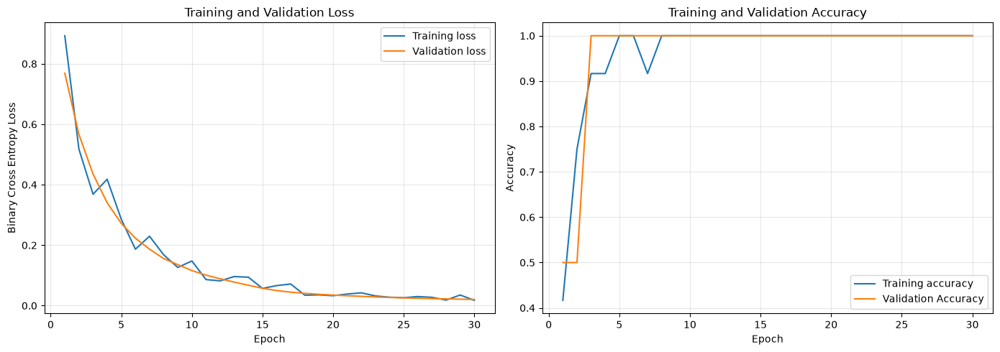

In [82]:
epochs_run = range(1, len(history.history["loss"]) +1)

fig, axes = plt.subplots(1,2, figsize = (14, 5))

axes[0].plot(
    epochs_run,
    history.history["loss"],
    label = "Training loss"
)

axes[0].plot(
    epochs_run,
    history.history["val_loss"],
    label = "Validation loss"
)

axes[0].set_title("Training and Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Cross Entropy Loss")
axes[0].legend()
axes[0].grid(alpha = 0.3)

axes[1].plot(
    epochs_run,
    history.history["accuracy"],
    label = "Training accuracy"
)

axes[1].plot(
    epochs_run,
    history.history["val_accuracy"],
    label="Validation Accuracy"
)    

axes[1].set_title("Training and Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [83]:


best_image_model= tf.keras.models.load_model(model_path)

evaluation_results= best_image_model.evaluate(
    X_validation,
    y_validation,
    verbose= 0,
    return_dict= True
)

print("Validation Results: ")

for metric_name, metric_values in evaluation_results.items():
    print(f"{metric_name}: {metric_values:.4f}")

Validation Results: 
accuracy: 1.0000
auc: 1.0000
loss: 0.0205
precision: 1.0000
recall: 1.0000


In [84]:
#Predictions

validation_probabilities = best_image_model.predict(
    X_validation,
    verbose=0
).ravel()

validation_predictions = (
    validation_probabilities >= 0.5 
).astype(np.int32)

print("Actual Labels:  ", y_validation)
print("Predicted Labels: ", validation_predictions)
print(
    "Foamy Probabilities:",
    np.round(validation_probabilities, 4)
)

Actual Labels:   [0 1 0 1 0 1]
Predicted Labels:  [0 1 0 1 0 1]
Foamy Probabilities: [0.0128 0.9909 0.0246 0.9823 0.0394 0.982 ]


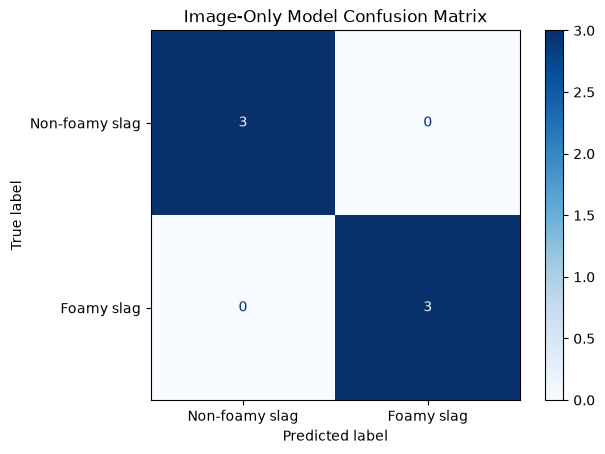

                precision    recall  f1-score   support

Non-foamy slag     1.0000    1.0000    1.0000         3
    Foamy slag     1.0000    1.0000    1.0000         3

      accuracy                         1.0000         6
     macro avg     1.0000    1.0000    1.0000         6
  weighted avg     1.0000    1.0000    1.0000         6

ROC-AUC: 1.000000


In [85]:
#Confusion matrix and classification report

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score
)

class_names = (
    "Non-foamy slag",
    "Foamy slag"
)

confusion = confusion_matrix(
    y_validation,
    validation_predictions,
    labels = [0,1]
)

display= ConfusionMatrixDisplay(
    confusion_matrix=confusion,
    display_labels=class_names
)

display.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("Image-Only Model Confusion Matrix")
plt.show()

print(
    classification_report(
        y_validation,
        validation_predictions,
        target_names=class_names,
        digits=4,
        zero_division= 0
    )
)

auc_score= roc_auc_score(
    y_validation,
    validation_probabilities
)

print(f"ROC-AUC: {auc_score:4f}")

The image-only prototype achieved perfect classification on the six-frame validation subset. 
However, because all frames originated from a single video and the slag classes coincided with different camera views, 
this result is likely influenced by temporal similarity and scene bias. 
It should be interpreted as proof of pipeline functionality rather than evidence of model generalisation.

In [86]:
#Generation of synthetic EAF data

# Reproducible random values
rng = np.random.default_rng(42)

number_of_samples = len(metadata_df)

slag_state = metadata_df["class_id"].to_numpy()

In [87]:
#Process variables

# ARc voltage in volts
arc_voltage_v = (
    650 
    - 15 * slag_state
    + rng.normal(0, 25, number_of_samples)
)

# Arc current in Kiloamperes
arc_current_ka = (
    48 
    + 2 * slag_state
    + rng.normal(0, 4, number_of_samples)
)

# Aproximate Power factor
power_factor = (
    0.85
    + rng.normal(0, 0.02, number_of_samples)
)

#Three Phase electrical power in MW
power_input_mw = (
    np.sqrt(3)
    * arc_voltage_v
    * arc_current_ka
    * power_factor
    / 1000
)

#Oxygen Flow
oxygen_flow_nm3_min = (
    35
    + 3 * slag_state
    + rng.normal(0, 3, number_of_samples)
)

#carbon_injection
carbon_inj_kg_min =(
    8
    + 2 * slag_state
    + rng.normal(0, 1.5, number_of_samples)
)

# Off gas temp
offgas_temp_c = (
    1050
    + 50 * slag_state
    + rng.normal(0, 60, number_of_samples)
)

#Offgas CO concentration in volume percent
offgas_co_pct = (
    10
    + 2 * slag_state
    + rng.normal(0, 2, number_of_samples)
)

#Offgas CO2 concentration in volume percent
offgas_co2_pct = (
    14
    - 1 * slag_state
    + rng.normal(0, 1.5, number_of_samples)
)


In [88]:
multimodal_df = metadata_df.copy()

multimodal_df["arc_voltage_v"] = np.round(
    arc_voltage_v, 2
)

multimodal_df["arc_current_ka"] = np.round(
    arc_current_ka, 2
)

multimodal_df["power_input_mw"] = np.round(
    power_input_mw, 2
)

multimodal_df["oxygen_flow_nm3_min"] = np.round(
    oxygen_flow_nm3_min, 2
)

multimodal_df["carbon_inj_kg_min"] = np.round(
    carbon_inj_kg_min, 2
)

multimodal_df["offgas_temp_c"] = np.round(
    offgas_temp_c, 2
)

multimodal_df["offgas_co_pct"] = np.round(
    offgas_co_pct, 2
)

multimodal_df["offgas_co2_pct"] = np.round(
    offgas_co2_pct, 2
)

multimodal_df.head()

,image_id,filename,timestamp_seconds,label,class_id,source_video,sequence_group,processed_filename,processed_width,processed_height,arc_voltage_v,arc_current_ka,power_input_mw,oxygen_flow_nm3_min,carbon_inj_kg_min,offgas_temp_c,offgas_co_pct,offgas_co2_pct
0,1,foamy_slag_001_0.00s.jpg,0.0,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_001_0.00s.jpg,224,224,657.62,51.51,49.74,33.59,6.62,1089.92,11.68,16.19
1,2,foamy_slag_002_0.50s.jpg,0.5,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_002_0.50s.jpg,224,224,624.00,47.80,43.05,33.08,8.75,1044.09,6.55,12.22
2,3,foamy_slag_003_1.00s.jpg,1.0,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_003_1.00s.jpg,224,224,668.76,47.26,45.63,34.17,8.21,1024.60,10.87,13.04
3,4,foamy_slag_004_1.50s.jpg,1.5,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_004_1.50s.jpg,224,224,673.51,45.28,45.58,39.48,9.04,1045.22,10.48,12.61
4,5,foamy_slag_005_2.00s.jpg,2.0,non_foamy_slag,0,slag video,sequence_1_wide_view,foamy_slag_005_2.00s.jpg,224,224,601.22,52.89,47.63,32.40,7.36,948.76,8.81,13.42


In [89]:
process_columns = [
    "arc_voltage_v",
    "arc_current_ka",
    "power_input_mw",
    "oxygen_flow_nm3_min",
    "carbon_inj_kg_min",
    "offgas_temp_c",
    "offgas_co_pct",
    "offgas_co2_pct"
]

from IPython.display import display as show_table

print("Dataset shape:", multimodal_df.shape)

print("\nMissing values:")
print(multimodal_df[process_columns].isnull().sum())



Dataset shape: (18, 18)

Missing values:
arc_voltage_v          0
arc_current_ka         0
power_input_mw         0
oxygen_flow_nm3_min    0
carbon_inj_kg_min      0
offgas_temp_c          0
offgas_co_pct          0
offgas_co2_pct         0
dtype: int64


In [90]:
# Saving the synchronized data

multimodal_dataset_path = os.path.join(
    image_folder,
    "multimodal_eaf_dataset.csv"
)

multimodal_df.to_csv(
    multimodal_dataset_path,
    index=False
)

print(
    f"Multimodal dataset saved to: "
    f"{multimodal_dataset_path}"
)

Multimodal dataset saved to: C:\Users\uched\Documents\EAF Research\Multi_Modal Project\foamy_slag_frames\multimodal_eaf_dataset.csv


In [91]:
from IPython.display import display as ipy_display

process_summary = (
    multimodal_df[
        process_columns + ["label"]
    ]
    .groupby("label")[process_columns]
    .mean()
    .round(2)
)

ipy_display(process_summary)

,arc_voltage_v,arc_current_ka,power_input_mw,oxygen_flow_nm3_min,carbon_inj_kg_min,offgas_temp_c,offgas_co_pct,offgas_co2_pct
label,,,,,,,,
foamy_slag,640.84,51.50,48.71,37.61,9.82,1091.56,12.82,13.68
non_foamy_slag,641.61,48.46,45.74,34.68,8.04,1014.62,9.51,13.23


In [92]:
#process features extraction

process_data = multimodal_df[
    process_columns
].to_numpy(dtype=np.float32)

print("Complete process-data shape:", process_data.shape)

Complete process-data shape: (18, 8)


In [93]:


# Index for every image/process-data pair
all_indices = np.arange(len(y))

train_indices, validation_indices = train_test_split(
    all_indices,
    test_size=1/3,
    random_state=42,
    stratify=y
)

# Split image data
X_train = X[train_indices]
X_validation = X[validation_indices]

# Split labels
y_train = y[train_indices]
y_validation = y[validation_indices]

# Convertion of  process variables into a NumPy array
process_data = multimodal_df[process_columns].to_numpy(dtype=np.float32)

# Splitting process data using exactly the same indices
process_train = process_data[train_indices]
process_validation = process_data[validation_indices]

In [94]:
print("Image training shape:", X_train.shape)
print("Process training shape:", process_train.shape)
print("Training-label shape:", y_train.shape)

print("\nImage validation shape:", X_validation.shape)
print("Process validation shape:", process_validation.shape)
print("Validation-label shape:", y_validation.shape)

print("\nTraining class counts:", np.bincount(y_train))
print("Validation class counts:", np.bincount(y_validation))

Image training shape: (12, 224, 224, 3)
Process training shape: (12, 8)
Training-label shape: (12,)

Image validation shape: (6, 224, 224, 3)
Process validation shape: (6, 8)
Validation-label shape: (6,)

Training class counts: [7 5]
Validation class counts: [3 3]


In [95]:
#Standardization

from sklearn.preprocessing import StandardScaler

process_scaler = StandardScaler()

# Learn mean and standard deviation from training data only
process_train_scaled = process_scaler.fit_transform(
    process_train
)

# Applying the training statistics to validation data
process_validation_scaled = process_scaler.transform(
    process_validation
)

In [96]:
#Verification of the standardized data

print("Scaled training shape:", process_train_scaled.shape)
print("Scaled validation shape:", process_validation_scaled.shape)

print(
    "\nTraining means:",
    np.round(process_train_scaled.mean(axis=0), 3)
)

print(
    "Training standard deviations:",
    np.round(process_train_scaled.std(axis=0), 3)
)

print("\nMissing values in training:",
      np.isnan(process_train_scaled).sum())

print("Missing values in validation:",
      np.isnan(process_validation_scaled).sum())

Scaled training shape: (12, 8)
Scaled validation shape: (6, 8)

Training means: [ 0. -0.  0. -0. -0.  0. -0.  0.]
Training standard deviations: [1. 1. 1. 1. 1. 1. 1. 1.]

Missing values in training: 0
Missing values in validation: 0


In [97]:
#Process Branch

from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    Concatenate,
    GlobalAveragePooling2D,
    Rescaling
)
from tensorflow.keras import Model
from tensorflow.keras.regularizers import l2

In [98]:
#The eight process measurements are converted into a learned 16-element feature vector

process_input = Input(
    shape=(len(process_columns),),
    name="process_input"
)

p = Dense(
    32,
    activation="relu",
    kernel_regularizer=l2(0.001),
    name="process_dense_1"
)(process_input)

p = BatchNormalization(
    name="process_batch_normalization"
)(p)

p = Dropout(
    0.20,
    name="process_dropout"
)(p)

process_features = Dense(
    16,
    activation="relu",
    name="process_feature_vector"
)(p)

In [99]:
#Recreating Image branch

image_input = Input(
    shape=(224, 224, 3),
    name="image_input"
)

i = data_augmentation(image_input)

i = Rescaling(
    scale=2.0,
    offset=-1.0,
    name="multimodal_image_rescaling"
)(i)

i = base_model(
    i,
    training=False
)

i = GlobalAveragePooling2D(
    name="multimodal_global_average_pooling"
)(i)

image_features = Dense(
    32,
    activation="relu",
    name="image_feature_projection"
)(i)

In [100]:
#Fusing Both

fused_features = Concatenate(
    name="feature_fusion"
)([
    image_features,
    process_features
])

In [101]:
#Adding the fused layer

x = Dense(
    32,
    activation="relu",
    kernel_regularizer=l2(0.001),
    name="fusion_dense"
)(fused_features)

x = Dropout(
    0.30,
    name="fusion_dropout"
)(x)

multimodal_output = Dense(
    1,
    activation="sigmoid",
    name="slag_prediction"
)(x)

In [103]:
#Complete Model

multimodal_model = Model(
    inputs=[
        image_input,
        process_input
    ],
    outputs=multimodal_output,
    name="multimodal_foamy_slag_model"
)

In [104]:
#Model Compilation

multimodal_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall"),
        tf.keras.metrics.AUC(name="auc")
    ]
)

multimodal_model.summary()

Model: "multimodal_foamy_slag_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ data_augmentation             │ (None, 224, 224, 3)       │               0 │ image_input[0][0]          │
│ (Sequential)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ process_input (InputLayer)    │ (None, 8)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multimodal_image_rescaling    │ (None, 224, 224, 3)       │               0 │ data_augmentation[1][0]    │
│ (Rescaling)                   │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ process_dense_1 (Dense)       │ (None, 32)                │             288 │ process_input[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ mobilenetv2_1.00_224          │ (None, 7, 7, 1280)        │       2,257,984 │ multimodal_image_rescalin… │
│ (Functional)                  │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ process_batch_normalization   │ (None, 32)                │             128 │ process_dense_1[0][0]      │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ multimodal_global_average_po… │ (None, 1280)              │               0 │ mobilenetv2_1.00_224[1][0] │
│ (GlobalAveragePooling2D)      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ process_dropout (Dropout)     │ (None, 32)                │               0 │ process_batch_normalizati… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ image_feature_projection      │ (None, 32)                │          40,992 │ multimodal_global_average… │
│ (Dense)                       │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ process_feature_vector        │ (None, 16)                │             528 │ process_dropout[0][0]      │
│ (Dense)                       │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ feature_fusion (Concatenate)  │ (None, 48)                │               0 │ image_feature_projection[… │
│                               │                           │                 │ process_feature_vector[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ fusion_dense (Dense)          │ (None, 32)                │           1,568 │ feature_fusion[0][0]       │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 2,301,521 (8.78 MB)

 Trainable params: 43,473 (169.82 KB)

 Non-trainable params: 2,258,048 (8.61 MB)

In [107]:
#Multi-modal Training

multimodal_model_path = (
    r"C:\Users\uched\Documents\EAF Research"
    r"\Multi_Modal Project\best_multimodal_model.keras"
)

multimodal_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=multimodal_model_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

In [108]:
#Model Training

multimodal_history = multimodal_model.fit(
    {
        "image_input": X_train,
        "process_input": process_train_scaled
    },
    y_train,

    validation_data=(
        {
            "image_input": X_validation,
            "process_input": process_validation_scaled
        },
        y_validation
    ),

    epochs=30,
    batch_size=4,
    callbacks=multimodal_callbacks,
    verbose=1
)

Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.6667 - auc: 0.6286 - loss: 0.6936 - precision: 0.6667 - recall: 0.4000     
Epoch 1: val_loss improved from None to 0.57313, saving model to C:\Users\uched\Documents\EAF Research\Multi_Modal Project\best_multimodal_model.keras

Epoch 1: finished saving model to C:\Users\uched\Documents\EAF Research\Multi_Modal Project\best_multimodal_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6667 - auc: 0.6286 - loss: 0.6936 - precision: 0.6667 - recall: 0.4000 - val_accuracy: 1.0000 - val_auc: 1.0000 - val_loss: 0.5731 - val_precision: 1.0000 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.9167 - auc: 0.8857 - loss: 0.5319 - precision: 1.0000 - recall: 0.8000
Epoch 2: val_loss improved from 0.57313 to 0.46699, saving model to C:\Users\uched\Documents\EAF Research\Multi_Modal Project\best_multimodal_model.keras

Epoch 2: finished saving model to C:\Users\uche

In [110]:
#Recorded Values

best_epoch = (
    np.argmin(multimodal_history.history["val_loss"]) + 1
)

best_validation_loss = np.min(
    multimodal_history.history["val_loss"]
)

best_validation_accuracy = np.max(
    multimodal_history.history["val_accuracy"]
)

print("Best epoch:", best_epoch)

print(
    "Lowest validation loss:",
    round(best_validation_loss, 4)
)

print(
    "Highest validation accuracy:",
    round(best_validation_accuracy, 4)
)

Best epoch: 30
Lowest validation loss: 0.0453
Highest validation accuracy: 1.0


In [111]:
#Evaluation of the multimodal model

best_multimodal_model = tf.keras.models.load_model(
    multimodal_model_path
)

multimodal_results = best_multimodal_model.evaluate(
    {
        "image_input": X_validation,
        "process_input": process_validation_scaled
    },
    y_validation,
    verbose=0,
    return_dict=True
)

print("Multimodal validation results:")

for metric_name, metric_value in multimodal_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

Multimodal validation results:
accuracy: 1.0000
auc: 1.0000
loss: 0.0453
precision: 1.0000
recall: 1.0000


In [112]:
#Prediction

multimodal_probabilities = best_multimodal_model.predict(
    {
        "image_input": X_validation,
        "process_input": process_validation_scaled
    },
    verbose=0
).ravel()

multimodal_predictions = (
    multimodal_probabilities >= 0.5
).astype(np.int32)

print("Actual labels:       ", y_validation)
print("Predicted labels:    ", multimodal_predictions)
print(
    "Foamy probabilities:",
    np.round(multimodal_probabilities, 4)
)

Actual labels:        [0 1 0 1 0 1]
Predicted labels:     [0 1 0 1 0 1]
Foamy probabilities: [2.000e-04 9.979e-01 9.000e-04 9.980e-01 6.000e-03 9.983e-01]


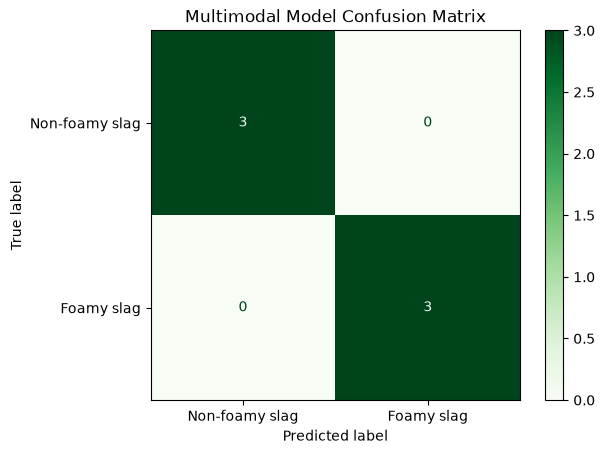

In [113]:
#Confusion Matrix

multimodal_confusion = confusion_matrix(
    y_validation,
    multimodal_predictions,
    labels=[0, 1]
)

cm_plot = ConfusionMatrixDisplay(
    confusion_matrix=multimodal_confusion,
    display_labels=[
        "Non-foamy slag",
        "Foamy slag"
    ]
)

cm_plot.plot(
    cmap="Greens",
    values_format="d"
)

plt.title("Multimodal Model Confusion Matrix")
plt.show()

In [114]:
print(
    classification_report(
        y_validation,
        multimodal_predictions,
        target_names=[
            "Non-foamy slag",
            "Foamy slag"
        ],
        digits=4,
        zero_division=0
    )
)

                precision    recall  f1-score   support

Non-foamy slag     1.0000    1.0000    1.0000         3
    Foamy slag     1.0000    1.0000    1.0000         3

      accuracy                         1.0000         6
     macro avg     1.0000    1.0000    1.0000         6
  weighted avg     1.0000    1.0000    1.0000         6



In [115]:
image_results = best_image_model.evaluate(
    X_validation,
    y_validation,
    verbose=0,
    return_dict=True
)

In [116]:
comparison_df = pd.DataFrame({
    "Image-only model": {
        "Loss": image_results["loss"],
        "Accuracy": image_results["accuracy"],
        "Precision": image_results["precision"],
        "Recall": image_results["recall"],
        "AUC": image_results["auc"]
    },

    "Multimodal model": {
        "Loss": multimodal_results["loss"],
        "Accuracy": multimodal_results["accuracy"],
        "Precision": multimodal_results["precision"],
        "Recall": multimodal_results["recall"],
        "AUC": multimodal_results["auc"]
    }
}).round(4)

comparison_df

,Image-only model,Multimodal model
Loss,0.0205,0.0453
Accuracy,1.0000,1.0000
Precision,1.0000,1.0000
Recall,1.0000,1.0000
AUC,1.0000,1.0000
